PS: before running the notebook, please make sure that the following libraries: `pylangacq and nltk` are installed.

Installation steps (and references):

1. PyLangAcq: `pip install --upgrade pylangacq`

https://pylangacq.org/index.html

2. NLTK: `pip install --user -U nltk`

https://www.nltk.org/install.html

Post installation of the libraries, data setup needs to configured:

PyLangAcq would work with the data being present in a directory in the current folder. You only need to extract the zip file in the same folder in which the notebook is present: `EllisWeismer.zip` 

For NLTK, the data would need to copied to the correct path and the NLTK_DATA environment variable would need to be set.

Follow the below steps to achieve this (reference in case you're stuck:- 'Manual Installation' section in the link: https://www.nltk.org/data.html):
1) create a folder `nltk_data` in your main user folder
2) extract and copy the contents of `corpora_for_nltk.zip` in folder created in (1)
3) set the enviromment variable `NLTK_DATA` to point to the folder created in (1)

The corpus should now be set in the following path in your user folder: `'nltk_data/corpora/childes/data-xml/Clinical-Eng/EllisWeismer'` (similar to the screenshot below):

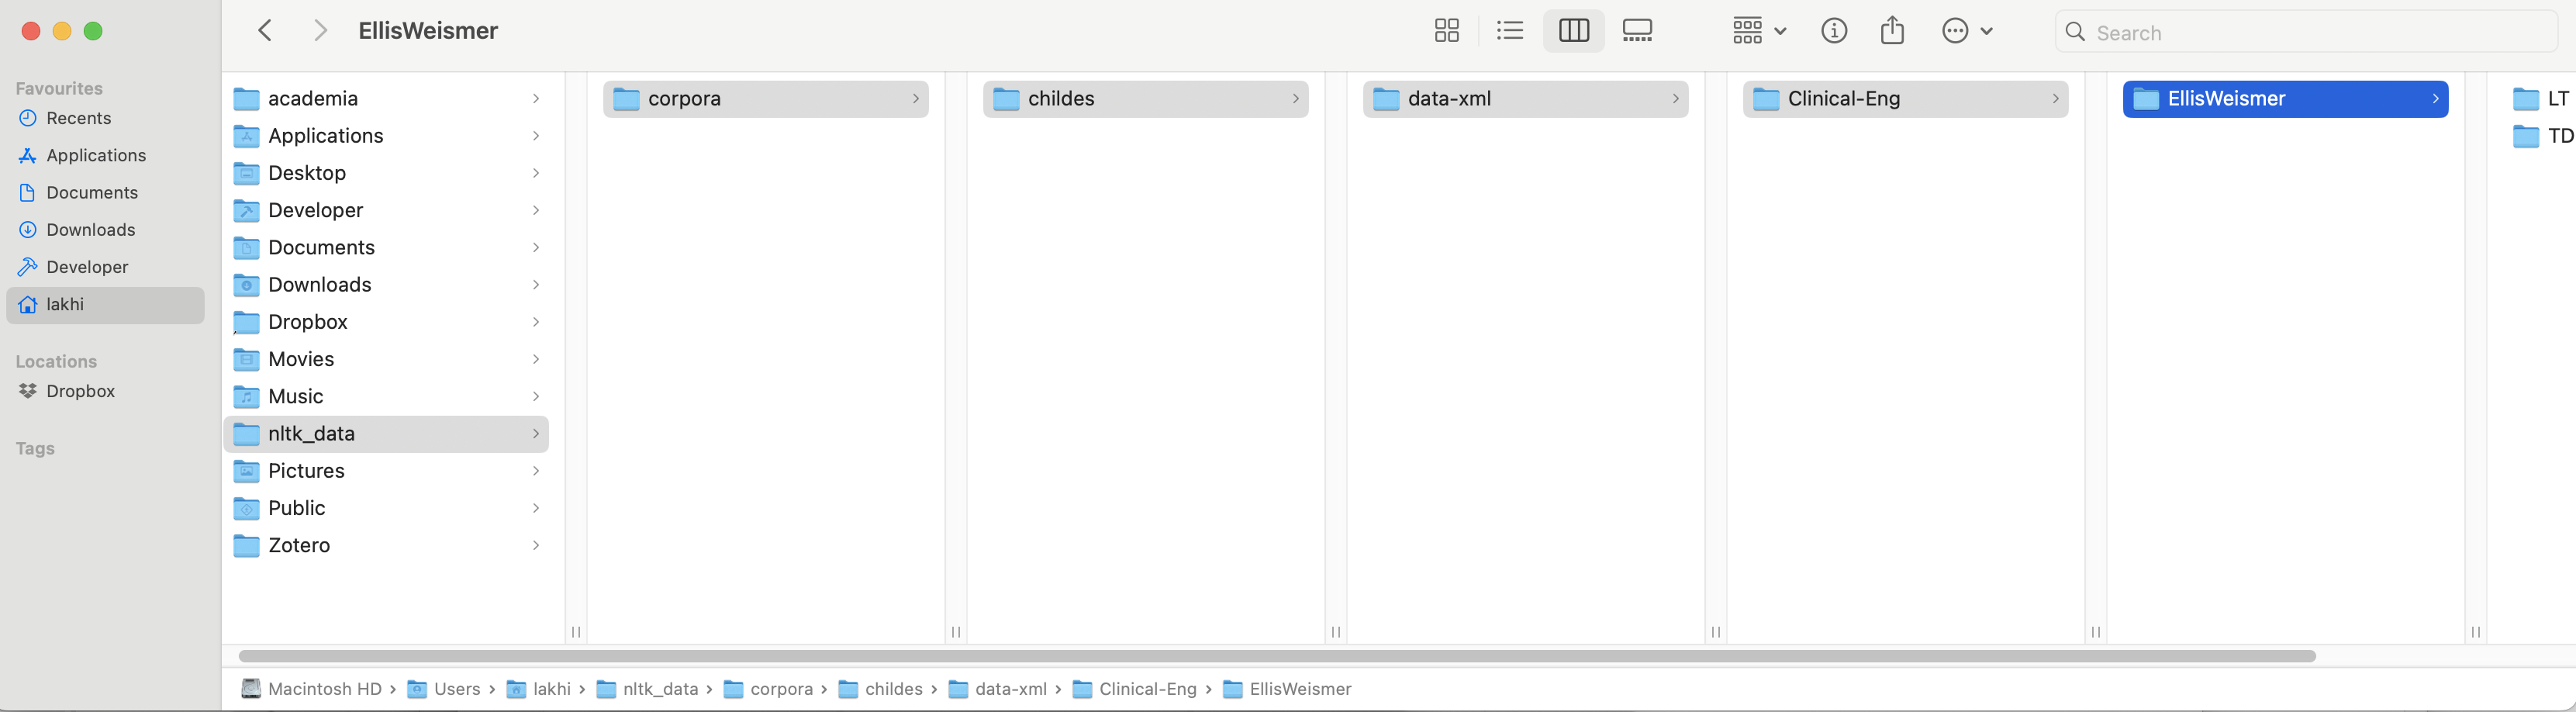

💡 In case of difficulty in any of the installation steps, please reach out to me (lakhia92@univie.ac.at or +43 670 1900155) so that we can quickly do the setup over a zoom call

Also, if execution of the first code cell (below) fails, the installation was not successful or the python environment where it was installed is not the one being used by the notebook

# 1. Data Initialisation

In [ ]:
import pylangacq
import nltk
from nltk.corpus.reader import CHILDESCorpusReader

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
from enum import Enum

class IsLateTalker(Enum):
    TD = 0 # Typical Development
    LT = 1 # Late Talker

In [ ]:
# NLTK data initialization (should print 574)
nltk_corpus_root = nltk.data.find('corpora/childes/data-xml/Clinical-Eng/EllisWeismer')
nltk_data = CHILDESCorpusReader(nltk_corpus_root, '.*.xml')
print(len(nltk_data.fileids()))

In [ ]:
# pylangacq data initialization (should print 574)
pyacq_corpus_url = "EllisWeismer/"
pyacq_data = pylangacq.Reader.from_dir(pyacq_corpus_url)
print(pyacq_data.n_files())

In [ ]:
# basic dataframe initialization with 3 columns
child_ids_df = pd.read_csv('child_ids.csv')
df = child_ids_df.set_index('child_id')
child_ids_df.info()

In [ ]:
CHAT_CATEGORIES = ['30ec', '30pc', '42ec', '42pc', '54ec', '54int', '66conv']

# filtering over a particular chat category for sanity check (should print 65)
pyacq_data.filter(IsLateTalker.TD.name).filter('30ec').n_files()

In [ ]:
# df is the default dataframe for the notebook that will be operated on by pylangacq, whereas df_nltk is for nltk
df_nltk = df.copy()
df_nltk

In [ ]:
# the main dataframe initialisation code block. prints the child type, chat type and the number of files processed for sanity check

CHILD_ID_START_INDEX = -9
CHILD_ID_END_INDEX = -4

for child_type in IsLateTalker:
    for chat_type in CHAT_CATEGORIES:
        print(child_type.name, chat_type, pyacq_data.filter(child_type.name).filter(chat_type).n_files())
        chat_type_mlum = chat_type + '_mlum'
        chat_type_mluw = chat_type + '_mluw'
        chat_type_ttr = chat_type + '_ttr'
        chat_type_ipsyn = chat_type + '_ipsyn'

        current_folder = pyacq_data.filter(child_type.name).filter(chat_type)
        for chat in current_folder:
            child_id = int(chat.file_paths()[0][CHILD_ID_START_INDEX:CHILD_ID_END_INDEX]) # extracts file name (which is the child_id) from the path
            if child_id in df.index:
                df.loc[child_id, chat_type_mlum] = chat.mlu()[0]
                df.loc[child_id, chat_type_mluw] = chat.mluw()[0]
                df.loc[child_id, chat_type_ttr] = chat.ttr()[0]
                df.loc[child_id, chat_type_ipsyn] = chat.ipsyn()[0]

In [ ]:
df.head()

In [ ]:
# the main dataframe initialisation code block through NLTK data only for MLUm (Mean Length of Utterance in morphemes) comparison

for child_type in IsLateTalker:
    for chat_type in CHAT_CATEGORIES:
        chat_type_mlum = chat_type + '_mlum'

        for fileid in nltk_data.fileids():
            file_parts = fileid.split('/')
            if len(file_parts) > 3: # some exceptions in the standardized file paths; for example, 'LT/66conv/0noaudio/11052.xml', etc.
                file_child_type, file_chat_type, file_name = file_parts[0], file_parts[1], file_parts[3]
            else:
                file_child_type, file_chat_type, file_name = file_parts[0], file_parts[1], file_parts[2]
            file_child_id = int(file_name[:-4])

            if file_child_type == child_type.name and file_chat_type == chat_type and file_child_id in df_nltk.index:
                df_nltk.loc[file_child_id, chat_type_mlum] = nltk_data.MLU(fileids=fileid)[0]

In [ ]:
df_nltk.head()

### showing that the MLU function in NLTK’s `ChildesCorpusReader` calculates MLU (morphemes):

https://github.com/nltk/nltk/blob/develop/nltk/corpus/reader/childes.py

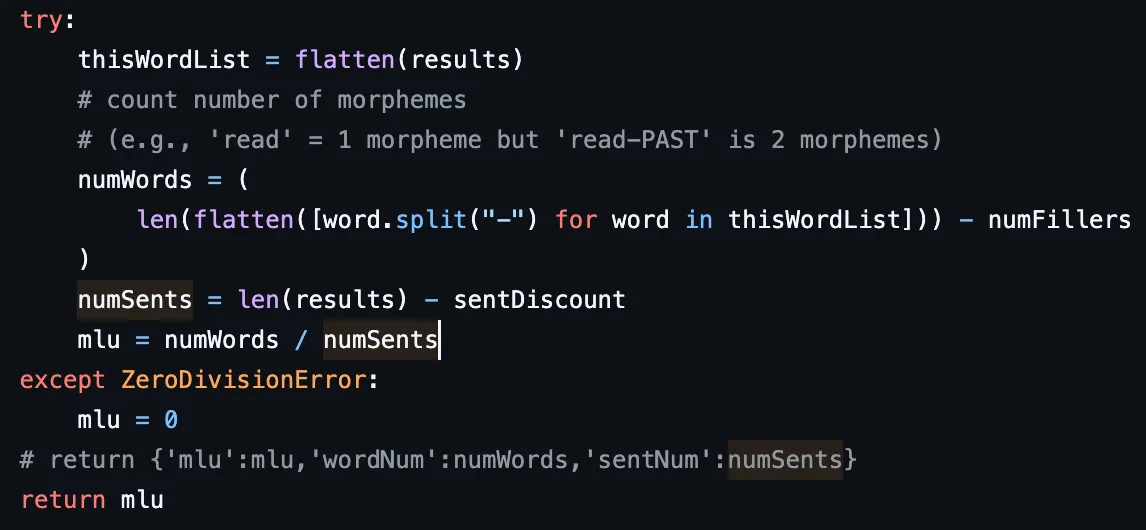

# 2. Data Visualisation

In [ ]:
# function to avoid code duplication for bar plot drawing

def draw_td_lt_barplot(df, comparison_param, plot_labels):
    """
    Function to draw a comparison plot between typical development and late talker groups for a given parameter.
    """
    # Filter the dataframe
    comparison_prefixes = ['30ec', '30pc', '42ec', '42pc', '54ec', '54int', '66conv']
    comparison_variables = [f'{prefix}_{comparison_param}' for prefix in comparison_prefixes]
    comparison_variables.append('is_late_talker')
    df_filtered = df[comparison_variables]
    
    # Melt the dataframe to long format for seaborn
    df_melted = df_filtered.melt(id_vars='is_late_talker', var_name='parameter', value_name='value')

    # Create the bar plot
    plt.figure(figsize=(12, 6))
    barplot =sns.barplot(data=df_melted, x='parameter', y='value', hue='is_late_talker')
    plt.title(f'Comparison of {plot_labels['title_name']} between Typical Development and Late Talker')
    plt.xlabel(plot_labels['xlabel'])
    plt.ylabel(plot_labels['ylabel'])
    plt.legend(title='Is Late Talker', labels=['Typical Development', 'Late Talker'])

    # Set the legend manually to match the colors
    handles, labels = barplot.get_legend_handles_labels()
    barplot.legend(handles=handles, labels=['Typical Development', 'Late Talker'], title='Child Type')

    ax = plt.gca()
    ax.set_xticks(range(len(comparison_prefixes)))
    ax.set_xticklabels(['2;6 yrs EC', '2;6 yrs PC', '3;6 yrs EC', '3;6 yrs PC', '4;6 yrs EC', '4;6 yrs INT', '5;6 yrs CONV'], rotation=45)

    plt.show()

In [ ]:
draw_td_lt_barplot(df, 'mlum', {'title_name': 'Mean Length of Utterance Morphemes (mlum)', 'xlabel': 'age (months) + chat type', 'ylabel': 'MLU (Morphemes)'})

In [ ]:
draw_td_lt_barplot(df, 'mluw', {'title_name': 'Mean Length of Utterance Words (mluw)', 'xlabel': 'age (months) + chat type', 'ylabel': 'MLU (Words)'})

In [ ]:
draw_td_lt_barplot(df, 'ttr', {'title_name': 'Type Token Ratio (ttr)', 'xlabel': 'age (months) + chat type', 'ylabel': 'TTR'})

In [ ]:
draw_td_lt_barplot(df, 'ipsyn', {'title_name': 'Index of Productive Syntax (IPSyn)', 'xlabel': 'age (months) + chat type', 'ylabel': 'IPSyn'})

In [ ]:
# boxplot comparison between TD and LT children for MLUm

comparison_prefixes = ['30ec', '30pc', '42ec', '42pc', '54ec', '54int', '66conv']
comparison_variables = [f'{prefix}_mlum' for prefix in comparison_prefixes]

comparison_variables.append('is_late_talker')
df_filtered = df[comparison_variables]

# Melt the dataframe to long format for seaborn
df_melted = df_filtered.melt(id_vars='is_late_talker', var_name='parameter', value_name='value')

# Create the bar plot
plt.figure(figsize=(12, 6))
boxplot = sns.boxplot(x='parameter', y='value', hue='is_late_talker', data=df_melted)
plt.xticks(rotation=45)
plt.title('Comparison of Mean Length of Utterance (Morphemes) between TD and LT children')
plt.xlabel('age (motnhs) + chat type')
plt.ylabel('MLU (Morphemes)')

# Set the legend manually to match the colors
handles, labels = boxplot.get_legend_handles_labels()
boxplot.legend(handles=handles, labels=['Typical Development', 'Late Talker'], title='Child Type')

ax = plt.gca()
ax.set_xticks(range(len(comparison_prefixes)))
ax.set_xticklabels(['2;6 yrs EC', '2;6 yrs PC', '3;6 yrs EC', '3;6 yrs PC', '4;6 yrs EC', '4;6 yrs INT', '5;6 yrs CONV'], rotation=45)

plt.show()

In [ ]:
# line plot comparison between TD and LT children for MLUm

# Melt the dataframe to long format for seaborn
df_melted = df.melt(id_vars=['gender', 'is_late_talker'], value_vars=[f'{prefix}_mlum' for prefix in comparison_prefixes], var_name='parameter', value_name='value')

plt.figure(figsize=(12, 6))
lineplot = sns.lineplot(data=df_melted, x='parameter', y='value', hue='is_late_talker', style='gender', markers=True, dashes=False)
plt.title('MLU (Morphemes) for Each Child Across Different Age Groups and Chat Types')
plt.xlabel('Age (months) + Chat Type')
plt.ylabel('MLU (Morphemes)')
plt.legend(title='Is Late Talker', labels=['Typical Development', 'Late Talker'])

ax = plt.gca()
ax.set_xticks(range(len(comparison_prefixes)))
ax.set_xticklabels(['2;6 yrs EC', '2;6 yrs PC', '3;6 yrs EC', '3;6 yrs PC', '4;6 yrs EC', '4;6 yrs INT', '5;6 yrs CONV'], rotation=45)

plt.show()

In [ ]:
# violion plot comparison between TD and LT children for MLUm

# Melt the dataframe to long format for seaborn
df_melted = df.melt(id_vars=['is_late_talker'], value_vars=[f'{prefix}_mlum' for prefix in comparison_prefixes], var_name='parameter', value_name='value')

# Create the violin plot
plt.figure(figsize=(12, 6))
violinplot = sns.violinplot(data=df_melted, x='parameter', y='value', hue='is_late_talker', split=True)
plt.title('Distribution of MLUM Parameters between Typical Development and Late Talker')
plt.xlabel('Age (months) + Chat Type')
plt.ylabel('MLU (Morphemes)')
plt.legend(title='Is Late Talker', labels=['Typical Development', 'Late Talker'])

# Set the x-axis labels
ax = plt.gca()
ax.set_xticks(range(len(comparison_prefixes)))
ax.set_xticklabels(['2;6 yrs EC', '2;6 yrs PC', '3;6 yrs EC', '3;6 yrs PC', '4;6 yrs EC', '4;6 yrs INT', '5;6 yrs CONV'], rotation=45)

plt.show()

# 3. Data Analysis

The two code blocks below show the comparison in absolute numbers between the Mean Length of Utterance (words and morphemes) between LT and TD children. MLUM and MLUW are the parameters we use for the analysis as they are reliable measures of language production (as explained in the document)

In [ ]:
mlum_pivot = df.pivot_table(index='is_late_talker', values=['30ec_mlum', '30pc_mlum', '42ec_mlum', '42pc_mlum', '54ec_mlum', '54int_mlum', '66conv_mlum'], aggfunc='mean').round(1)
mlum_pivot

In [ ]:
mluw_pivot = df.pivot_table(index='is_late_talker', values=['30ec_mluw', '30pc_mluw', '42ec_mluw', '42pc_mluw', '54ec_mluw', '54int_mluw', '66conv_mluw'], aggfunc='mean').round(1)
mluw_pivot

In [ ]:
# Trend Analysis of the Mean of MLUM over time (which shows a clear difference between TD and LT children)

plt.figure(figsize=(12, 6))
ax = mlum_pivot.T.plot(kind='line', marker='o')
plt.title('Mean of MLUM over time')
plt.xlabel('Age (with chat type)')
# tilt the x-axis labels
ax.set_xticks(range(len(mlum_pivot.columns)))
ax.set_xticklabels(['2;6 yrs EC', '2;6 yrs PC', '3;6 yrs EC', '3;6 yrs PC', '4;6 yrs EC', '4;6 yrs INT', '5;6 yrs CONV'], rotation=45)
plt.ylabel('MLU (Morphemes) value')
plt.legend(title='Child Type', labels=['Typical Development', 'Late Talker'])
plt.show()

In [ ]:
# Trend Analysis of the Mean of MLUW over time (which shows a clear difference between TD and LT children)

# plot mluw_pivot as a line plot
plt.figure(figsize=(12, 6))
ax = mluw_pivot.T.plot(kind='line', marker='x')
plt.title('Mean of MLUW over time')
plt.xlabel('Age (with chat type)')
# tilt the x-axis labels
ax.set_xticks(range(len(mluw_pivot.columns)))
ax.set_xticklabels(['2;6 yrs EC', '2;6 yrs PC', '3;6 yrs EC', '3;6 yrs PC', '4;6 yrs EC', '4;6 yrs INT', '5;6 yrs CONV'], rotation=45)
plt.ylabel('MLU (Words) value')
plt.legend(title='Child Type', labels=['Typical Development', 'Late Talker'])
plt.show()

The two code blocks below show the disparity in MLUM scores between `PyLangAcq and NLTK`. 

NLTK provides the more accurate scores (which are closer to existing literature)

In [ ]:
df.pivot_table(index='is_late_talker', values=['30ec_mlum', '30pc_mlum', '42ec_mlum', '42pc_mlum', '54ec_mlum', '54int_mlum', '66conv_mlum'], aggfunc=['mean', 'std']).round(1)

In [ ]:
df_nltk.pivot_table(index='is_late_talker', values=['30ec_mlum', '30pc_mlum', '42ec_mlum', '42pc_mlum', '54ec_mlum', '54int_mlum', '66conv_mlum'], aggfunc=['mean', 'std']).round(1)

# 4. Word Frequency Visualisations (Additional)

In [ ]:
td_word_frequencies = {}
lt_word_frequencies = {}

for child_type in IsLateTalker:
    for chat_type in CHAT_CATEGORIES:
        current_folder_reader = pyacq_data.filter(child_type.name).filter(chat_type)
        folder_child_frequencies = current_folder_reader.word_frequencies(keep_case=False, participants='CHI')
        if child_type == IsLateTalker.TD:
            td_word_frequencies[chat_type] = folder_child_frequencies
        else:
            lt_word_frequencies[chat_type] = folder_child_frequencies

print(td_word_frequencies)
print(lt_word_frequencies)

In [ ]:
import string

articles = ['a', 'an', 'the']

def remove_punctuation_and_articles(counter):
    for punct in string.punctuation:
        if punct in counter:
            del counter[punct]
    for article in articles:
        if article in counter:
            del counter[article]

# Remove punctuation and articles from td_word_frequencies
for chat_type in td_word_frequencies:
    remove_punctuation_and_articles(td_word_frequencies[chat_type])

# Remove punctuation and articles from lt_word_frequencies
for chat_type in lt_word_frequencies:
    remove_punctuation_and_articles(lt_word_frequencies[chat_type])

print(td_word_frequencies)
print(lt_word_frequencies)

In [ ]:
# Convert the Counter to a DataFrame
td_30ec_df = pd.DataFrame.from_dict(td_word_frequencies['30ec'], orient='index', columns=['frequency']).reset_index()
td_30ec_df = td_30ec_df.rename(columns={'index': 'word'})

# Sort the DataFrame by frequency
td_30ec_df = td_30ec_df.sort_values(by='frequency', ascending=False).head(20)  # Get top 20 words

# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(data=td_30ec_df, x='frequency', y='word', hue='word', legend=False)
plt.title('Top 20 Word Frequencies in Typical Development (30ec)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [ ]:
# Convert the Counter to DataFrames
td_30ec_df = pd.DataFrame.from_dict(td_word_frequencies['30ec'], orient='index', columns=['frequency']).reset_index()
td_30ec_df = td_30ec_df.rename(columns={'index': 'word'})
td_30ec_df['child_type'] = 'Typical Development'

lt_30ec_df = pd.DataFrame.from_dict(lt_word_frequencies['30ec'], orient='index', columns=['frequency']).reset_index()
lt_30ec_df = lt_30ec_df.rename(columns={'index': 'word'})
lt_30ec_df['child_type'] = 'Late Talker'

# Combine the DataFrames
combined_df = pd.concat([td_30ec_df, lt_30ec_df])

# Sort the DataFrame by frequency and get the top 20 words
top_words_df = combined_df.groupby('word').sum().sort_values(by='frequency', ascending=False).head(20).reset_index()
combined_df = combined_df[combined_df['word'].isin(top_words_df['word'])]

# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_df, x='frequency', y='word', hue='child_type', palette='viridis')
plt.title('Top 20 Word Frequencies in Typical Development (TD) and Late Talker (LT) - 30ec')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.legend(title='Child Type')
plt.show()

In [ ]:
# it would be useful to receive feedback on the analysis. thank you!

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

In [ ]:
def build_late_talker_classifier(df, features):
    X = df[features].dropna()
    y = df.loc[X.index, 'is_late_talker']

    # Split the data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the classifier
    # clf = RandomForestClassifier(random_state=42, min_samples_leaf=2, max_features='sqrt')
    clf = GradientBoostingClassifier(random_state=42, min_samples_leaf=2, max_features='sqrt', learning_rate=0.1)
    # clf = DecisionTreeClassifier(random_state=42, min_samples_leaf=2, max_features='sqrt')
    clf.fit(x_train, y_train)

    y_pred = clf.predict(x_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy:.2f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

    # Plot the feature importances
    feature_names = x_train.columns
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importance")
    plt.bar(range(x_train.shape[1]), importances[indices], align="center")
    plt.xticks(range(x_train.shape[1]), feature_names[indices], rotation=45)
    plt.xlim([-1, x_train.shape[1]])
    plt.show()

In [ ]:
build_late_talker_classifier(df, features = ['30ec_mlum', '30ec_mluw', '30ec_ttr', '30ec_ipsyn', '30pc_mlum', '30pc_mluw', '30pc_ttr', '30pc_ipsyn'])

In [ ]:
build_late_talker_classifier(df, features = ['42ec_mlum', '42ec_mluw', '42ec_ttr', '42ec_ipsyn', '42pc_mlum', '42pc_mluw', '42pc_ttr', '42pc_ipsyn'])

# 5. Classifier Implementation - Explanation and Analysis

A classifier that determines whether the child is a `late_talker` based on it's developmental indicators calculated from the langauge corpus at an early age (2'6 yrs and 3'6 yrs) has been implemented. The accuracy of how well it determines whether the child is a `late_talker` has been assessed, along with analysing which developmental parameters predict this the most. Chat GPT has been used to understand the relevant classifiers in `sklearn` and measurements of their accuracy, and to write part of the code. The findings and analysis are shared as points below:
- `RandomForestClassifier`, `GradientBoostingClassifier`, and `DecisionTreeClassifier` were tried for the above problem. While the first two gave similar results (accuracy between 70-77%), the decision tree classifier consistenly had a lower accuracy. This can be checked by commenting/uncommenting the line for the classifiers in the main function
- While both `RandomForestClassifier` and `GradientBoostingClassifier` give accuracy scores in a similar range, the Gradient Boosting classifier performs marginally better, reaching the maximum accuracy score of 77% in the 2'6 yrs case. However, it requires tuning of an additional hyperparameter, the `learning_rate`. 0.1 was determined to be a good value for the above problem through manual trial and error
- Apart from the accuracy score, the classification_report function provides a detailed report of the main classification metrics, including precision, recall, and F1-score for each class. It also includes the support, which is the number of true instances for each class.
    - Precision: The ratio of correctly predicted positive observations to the total predicted positives.
    - Recall (Sensitivity): The ratio of correctly predicted positive observations to the all observations in actual class.
    - F1-score: The weighted average of Precision and Recall.
- We observe that for both early age groups (2'6 yrs and 3'6 yrs), the developmental indicators Mean Length of Utterance (Morphemes and Words) together contribute the highest amount in predicting whether the child is a late talker. **This aligns with our earlier analysis that the mean length of utterance is a reliable developmental measure for assessing language production in infants**